# 🔴 GAT Pipeline — Train on FakeNews & Predict on WelFake

**Graph Attention Network (GAT)** — nâng cấp so với GCN bằng cơ chế **attention** để tự động học độ quan trọng của từng neighbor.

---

## GCN vs GAT — Sự khác biệt cốt lõi

| | GCN | GAT |
|---|---|---|
| **Aggregation** | Trung bình có trọng số cố định (degree-based) | Trung bình có trọng số **học được** (attention) |
| **Neighbors** | Tất cả neighbors **bằng nhau** | Mỗi neighbor có **trọng số khác nhau** |
| **Multi-head** | ❌ | ✅ (nhiều head = nhiều góc nhìn) |
| **Interpretability** | Thấp | **Cao hơn** — có thể xem attention weights |
| **Inductive** | ❌ Transductive | ✅ **Inductive** hơn |

### Công thức GAT Attention:

$$h_i^{(l+1)} = \sigma\left(\sum_{j \in \mathcal{N}(i)} \alpha_{ij}^{(l)} W^{(l)} h_j^{(l)}\right)$$

Trong đó attention coefficient:
$$\alpha_{ij} = \text{softmax}_j\left(\text{LeakyReLU}\left(\mathbf{a}^\top [Wh_i \| Wh_j]\right)\right)$$

---

## Tổng quan pipeline

```
true.csv + fake.csv
       │
       ▼
 [1] Load & Preprocess Text
       │
       ▼
 [2] TF-IDF Feature Extraction  (2000 features)
       │
       ▼
 [3] KNN Graph Construction     (k=5)
       │
       ▼
 [4] GAT Model Training         (2-layer GAT, 4 heads, 150 epochs)
       │
       ▼
 [5] Evaluation + GCN Comparison (intra-dataset)
       │
       ▼
 [6] Attention Weight Analysis
       │
       ▼
 [7] Save Checkpoint
       │
       ▼
 [8] Cross-dataset Prediction on WelFake (GAT vs GCN)
       │
       ▼
 [9] Full 2×2 Comparison Table
```

---
## ⚙️ Cell 0 — Import thư viện & Cấu hình

In [1]:
import sys
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from datetime import datetime

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from scipy.sparse import csr_matrix
from scipy.stats import entropy as scipy_entropy

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch_geometric.nn import GATConv, GCNConv
from torch_geometric.data import Data

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device          : {DEVICE}")

c:\Users\MINH\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version : 2.4.1+cpu
CUDA available  : False
Device          : cpu


In [2]:
# ── Tự động tìm PROJECT_ROOT ─────────────────────────────────────────────────
cwd = Path('.').resolve()
PROJECT_ROOT = cwd
for _ in range(4):
    if (PROJECT_ROOT / 'data').exists():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DIR        = PROJECT_ROOT / 'data' / 'raw'
CKPT_DIR       = PROJECT_ROOT / 'output' / 'checkpoints'
CKPT_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_GAT = CKPT_DIR / 'gat_fakenews.pt'
CHECKPOINT_GCN = CKPT_DIR / 'gcn_fakenews.pt'
WELFAKE_PATH   = RAW_DIR  / 'WELFake_Dataset.csv'

print(f"PROJECT_ROOT   : {PROJECT_ROOT}")
print(f"fake.csv       : {(RAW_DIR/'fake.csv').exists()}")
print(f"true.csv       : {(RAW_DIR/'true.csv').exists()}")
print(f"WelFake CSV    : {WELFAKE_PATH.exists()}")
print(f"GCN checkpoint : {CHECKPOINT_GCN.exists()} ← dùng để so sánh")

PROJECT_ROOT   : D:\code_vs\Python\Semester_6\Graph_Mining\Fake-News-Detection-GNN
fake.csv       : True
true.csv       : True
WelFake CSV    : True
GCN checkpoint : True ← dùng để so sánh


In [3]:
# ── Hyperparameters ─────────────────────────────────────────────────────────
# Data
SAMPLE_SIZE    = 44000  # Train/eval trên 44k article FakeNews
MAX_FEATURES   = 2000   # TF-IDF features
KNN_K          = 5      # KNN neighbors
TEST_RATIO     = 0.3
RANDOM_SEED    = 42
WELFAKE_SAMPLE = 3000   # Số article WelFake dùng cross-dataset

# GAT Architecture
GAT_HIDDEN    = 64     # Hidden dim per head
GAT_HEADS     = 4      # Number of attention heads (layer 1)
GAT_DROPOUT   = 0.5    # Dropout rate

# Training
EPOCHS        = 150
LEARNING_RATE = 5e-4
WEIGHT_DECAY  = 5e-4

print("GAT Hyperparameters:")
print(f"  SAMPLE_SIZE    = {SAMPLE_SIZE}")
print(f"  MAX_FEATURES   = {MAX_FEATURES}")
print(f"  KNN_K          = {KNN_K}")
print(f"  GAT_HIDDEN     = {GAT_HIDDEN}  (per head)")
print(f"  GAT_HEADS      = {GAT_HEADS}")
print(f"  → Layer1 out   = {GAT_HIDDEN * GAT_HEADS} (hidden × heads)")
print(f"  GAT_DROPOUT    = {GAT_DROPOUT}")
print(f"  EPOCHS         = {EPOCHS}")
print(f"  LR             = {LEARNING_RATE}")
print(f"  WEIGHT_DECAY   = {WEIGHT_DECAY}")
print(f"  WELFAKE_SAMPLE = {WELFAKE_SAMPLE}")

GAT Hyperparameters:
  SAMPLE_SIZE    = 44000
  MAX_FEATURES   = 2000
  KNN_K          = 5
  GAT_HIDDEN     = 64  (per head)
  GAT_HEADS      = 4
  → Layer1 out   = 256 (hidden × heads)
  GAT_DROPOUT    = 0.5
  EPOCHS         = 150
  LR             = 0.0005
  WEIGHT_DECAY   = 0.0005
  WELFAKE_SAMPLE = 3000


---
## 📂 Step 1 — Load & Preprocess FakeNews Data

In [4]:
print("=" * 60)
print("STEP 1: Loading & Preprocessing FakeNews Data")
print("=" * 60)

fake_df = pd.read_csv(RAW_DIR / 'fake.csv')
fake_df['label'] = 1
print(f"  ✓ Fake news : {len(fake_df):,} articles")

true_df = pd.read_csv(RAW_DIR / 'true.csv')
true_df['label'] = 0
print(f"  ✓ True news : {len(true_df):,} articles")

df = pd.concat([fake_df, true_df], ignore_index=True)
print(f"  ✓ Combined  : {len(df):,} articles")

def preprocess_text(text: str) -> str:
    text = str(text).lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    return ' '.join(text.split())

df['text']    = df['text'].astype(str).apply(preprocess_text)
df['title']   = df['title'].astype(str).apply(preprocess_text)
df['content'] = df['title'] + " " + df['text']

if SAMPLE_SIZE < 0:
    df_sample = df.reset_index(drop=True)
else:
    df_sample = df.sample(n=min(SAMPLE_SIZE, len(df)), random_state=RANDOM_SEED).reset_index(drop=True)

y_data = df_sample['label'].values
fake_count = (y_data == 1).sum()
real_count = (y_data == 0).sum()
print(f"  ✓ Sampled   : {len(df_sample):,} articles")
print(f"  ✓ Real: {real_count} ({real_count/len(y_data)*100:.1f}%)  |  Fake: {fake_count} ({fake_count/len(y_data)*100:.1f}%)")

STEP 1: Loading & Preprocessing FakeNews Data
  ✓ Fake news : 23,481 articles
  ✓ True news : 21,417 articles
  ✓ Combined  : 44,898 articles
  ✓ Sampled   : 44,000 articles
  ✓ Real: 21006 (47.7%)  |  Fake: 22994 (52.3%)


---
## 🧮 Step 2 — TF-IDF Feature Extraction & KNN Graph

In [5]:
print("=" * 60)
print("STEP 2: TF-IDF + KNN Graph")
print("=" * 60)

vectorizer     = TfidfVectorizer(max_features=MAX_FEATURES)
tfidf_matrix   = vectorizer.fit_transform(df_sample['content']).toarray()
scaler         = StandardScaler()
tfidf_features = scaler.fit_transform(tfidf_matrix)
print(f"  ✓ TF-IDF shape : {tfidf_features.shape}")

nbrs = NearestNeighbors(n_neighbors=KNN_K + 1, algorithm='auto', metric='cosine')
nbrs.fit(tfidf_features)
distances, indices = nbrs.kneighbors(tfidf_features)

rows, cols = [], []
for i in range(tfidf_features.shape[0]):
    for j in range(1, KNN_K + 1):
        rows.append(i)
        cols.append(indices[i][j])

data_val   = np.ones(len(rows))
adjacency  = csr_matrix((data_val, (rows, cols)),
                         shape=(tfidf_features.shape[0], tfidf_features.shape[0]))
adjacency  = adjacency.maximum(adjacency.transpose())
coo        = adjacency.tocoo()
edge_index = torch.tensor(np.array([coo.row, coo.col]), dtype=torch.long)

n_nodes, n_edges = adjacency.shape[0], adjacency.count_nonzero()
print(f"  ✓ Nodes          : {n_nodes:,}")
print(f"  ✓ Edges (undir.) : {n_edges:,}")
print(f"  ✓ Avg degree     : {n_edges / n_nodes:.2f}")

STEP 2: TF-IDF + KNN Graph
  ✓ TF-IDF shape : (44000, 2000)
  ✓ Nodes          : 44,000
  ✓ Edges (undir.) : 361,904
  ✓ Avg degree     : 8.23


In [6]:
# ── Build PyG Data + train/test masks ────────────────────────────────────────
X_tensor = torch.tensor(tfidf_features, dtype=torch.float32)
y_tensor = torch.tensor(y_data, dtype=torch.long)

pyg_data = Data(x=X_tensor, edge_index=edge_index, y=y_tensor)

idx_all = np.arange(len(y_data))
idx_train, idx_test = train_test_split(idx_all, test_size=TEST_RATIO, random_state=RANDOM_SEED)

train_mask = torch.zeros(len(y_data), dtype=torch.bool)
train_mask[idx_train] = True
test_mask  = torch.zeros(len(y_data), dtype=torch.bool)
test_mask[idx_test] = True

pyg_data.train_mask = train_mask
pyg_data.test_mask  = test_mask
pyg_data = pyg_data.to(DEVICE)

print(f"Train samples : {train_mask.sum().item():,}")
print(f"Test  samples : {test_mask.sum().item():,}")

Train samples : 30,800
Test  samples : 13,200


---
## 🧠 Step 3 — Định nghĩa GAT & GCN Models

### Kiến trúc 2-layer GAT:
```
Input (2000) → GATConv(64, heads=4, concat=True) → 256-dim → ELU → Dropout
             → GATConv(256 → 2, heads=1, concat=False) → Logits
```

### Kiến trúc 2-layer GCN (so sánh):
```
Input (2000) → GCNConv(128) → ReLU → GCNConv(2) → Logits
```

In [7]:
# ── GAT Model ─────────────────────────────────────────────────────────────────
class GATModel(nn.Module):
    """
    2-layer Graph Attention Network.
    Layer 1: Multi-head attention (concat=True)  → hidden * heads
    Layer 2: Single-head attention (concat=False) → out_channels
    """
    def __init__(self, in_channels, hidden_channels=64, out_channels=2, heads=4, dropout=0.5):
        super(GATModel, self).__init__()
        self.dropout = dropout
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=dropout, concat=True)
        self.conv2 = GATConv(hidden_channels * heads, out_channels, heads=1, dropout=dropout, concat=False)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.elu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.conv2(x, edge_index)

    def forward_with_attention(self, data):
        """Forward pass returning (logits, edge_index, attention_weights)."""
        x, edge_index = data.x, data.edge_index
        x = F.dropout(x, p=self.dropout, training=self.training)
        x, (attn_ei, alpha) = self.conv1(x, edge_index, return_attention_weights=True)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.conv2(x, edge_index), attn_ei, alpha


# ── GCN Model (for comparison) ────────────────────────────────────────────────
class GCNModel(nn.Module):
    """2-layer GCN for comparison."""
    def __init__(self, in_channels, hidden_channels=128, out_channels=2):
        super(GCNModel, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = torch.relu(self.conv1(x, edge_index))
        return self.conv2(x, edge_index)


# Instantiate GAT
model_gat = GATModel(
    in_channels=MAX_FEATURES, hidden_channels=GAT_HIDDEN,
    out_channels=2, heads=GAT_HEADS, dropout=GAT_DROPOUT
).to(DEVICE)

gat_params = sum(p.numel() for p in model_gat.parameters() if p.requires_grad)

print("GAT Architecture:")
print(model_gat)
print(f"\nGAT trainable parameters: {gat_params:,}")

# Dummy GCN for param count comparison
_gcn_tmp = GCNModel(in_channels=MAX_FEATURES).to(DEVICE)
gcn_params = sum(p.numel() for p in _gcn_tmp.parameters() if p.requires_grad)
print(f"GCN trainable parameters: {gcn_params:,}")
del _gcn_tmp

GAT Architecture:
GATModel(
  (conv1): GATConv(2000, 64, heads=4)
  (conv2): GATConv(256, 2, heads=1)
)

GAT trainable parameters: 513,286
GCN trainable parameters: 256,386


---
## 🚀 Step 4 — Train GAT Model

In [8]:
print("=" * 60)
print("STEP 4: Training GAT Model")
print(f"        Epochs={EPOCHS}  |  LR={LEARNING_RATE}  |  WD={WEIGHT_DECAY}")
print("=" * 60)

optimizer = optim.Adam(model_gat.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
loss_fn   = nn.CrossEntropyLoss()

train_losses, train_accs, test_accs = [], [], []
start_time = datetime.now()

for epoch in range(EPOCHS):
    model_gat.train()
    optimizer.zero_grad()
    out  = model_gat(pyg_data)
    loss = loss_fn(out[pyg_data.train_mask], pyg_data.y[pyg_data.train_mask])
    loss.backward()
    optimizer.step()

    model_gat.eval()
    with torch.no_grad():
        out_e      = model_gat(pyg_data)
        train_acc  = (out_e[pyg_data.train_mask].argmax(1) == pyg_data.y[pyg_data.train_mask]).float().mean().item()
        test_acc   = (out_e[pyg_data.test_mask].argmax(1)  == pyg_data.y[pyg_data.test_mask]).float().mean().item()

    train_losses.append(loss.item())
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    if epoch % 10 == 0 or epoch == EPOCHS - 1:
        print(f"  Epoch {epoch:3d}/{EPOCHS}  |  Loss: {loss.item():.4f}  |  Train: {train_acc:.4f}  |  Test: {test_acc:.4f}")

elapsed = (datetime.now() - start_time).total_seconds()
print(f"\n  ✓ Training completed in {elapsed:.1f}s")

STEP 4: Training GAT Model
        Epochs=150  |  LR=0.0005  |  WD=0.0005
  Epoch   0/150  |  Loss: 1.9447  |  Train: 0.7082  |  Test: 0.7075
  Epoch  10/150  |  Loss: 0.6442  |  Train: 0.8626  |  Test: 0.8621
  Epoch  20/150  |  Loss: 0.5289  |  Train: 0.8878  |  Test: 0.8852
  Epoch  30/150  |  Loss: 0.4443  |  Train: 0.9009  |  Test: 0.8961
  Epoch  40/150  |  Loss: 0.4067  |  Train: 0.9064  |  Test: 0.8988
  Epoch  50/150  |  Loss: 0.3769  |  Train: 0.9106  |  Test: 0.9027
  Epoch  60/150  |  Loss: 0.3551  |  Train: 0.9148  |  Test: 0.9055
  Epoch  70/150  |  Loss: 0.3376  |  Train: 0.9174  |  Test: 0.9072
  Epoch  80/150  |  Loss: 0.3221  |  Train: 0.9206  |  Test: 0.9091
  Epoch  90/150  |  Loss: 0.3098  |  Train: 0.9225  |  Test: 0.9102
  Epoch 100/150  |  Loss: 0.2951  |  Train: 0.9236  |  Test: 0.9117
  Epoch 110/150  |  Loss: 0.2918  |  Train: 0.9253  |  Test: 0.9114
  Epoch 120/150  |  Loss: 0.2860  |  Train: 0.9263  |  Test: 0.9128
  Epoch 130/150  |  Loss: 0.2806  |  Train

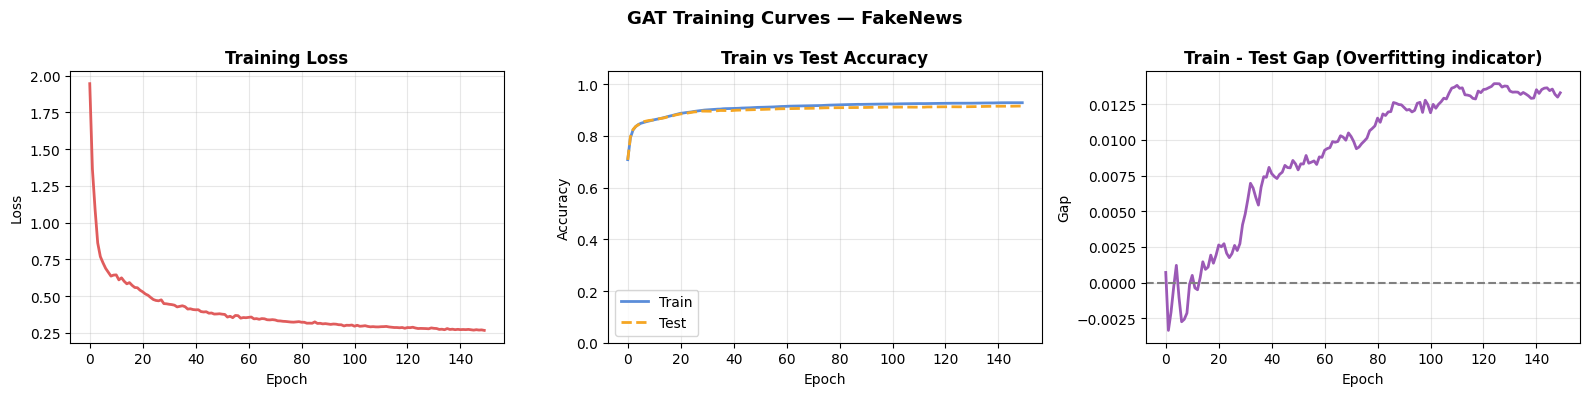

In [9]:
# ── Visualisation: Training curves ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(range(EPOCHS), train_losses, color='#E05C5C', linewidth=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss', fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(EPOCHS), train_accs, color='#5B8DD9', linewidth=2, label='Train')
axes[1].plot(range(EPOCHS), test_accs,  color='#F5A623', linewidth=2, linestyle='--', label='Test')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Train vs Test Accuracy', fontweight='bold')
axes[1].set_ylim(0, 1.05); axes[1].legend(); axes[1].grid(True, alpha=0.3)

gap = [tr - te for tr, te in zip(train_accs, test_accs)]
axes[2].plot(range(EPOCHS), gap, color='#9B59B6', linewidth=2)
axes[2].axhline(0, color='gray', linestyle='--')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Gap')
axes[2].set_title('Train - Test Gap (Overfitting indicator)', fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.suptitle('GAT Training Curves — FakeNews', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 📊 Step 5 — Evaluation & So sánh GCN vs GAT (FakeNews)

In [10]:
print("=" * 60)
print("STEP 5: GAT Evaluation on FakeNews Test Set")
print("=" * 60)

model_gat.eval()
with torch.no_grad():
    out_final = model_gat(pyg_data)
    pred_test = out_final[pyg_data.test_mask].argmax(dim=1).cpu().numpy()
    y_test    = pyg_data.y[pyg_data.test_mask].cpu().numpy()
    gat_fn_acc = accuracy_score(y_test, pred_test)

print(f"\n  ✅ GAT Test Accuracy on FakeNews : {gat_fn_acc:.4f} ({gat_fn_acc*100:.2f}%)\n")
print(classification_report(y_test, pred_test, target_names=['Real (0)', 'Fake (1)']))

STEP 5: GAT Evaluation on FakeNews Test Set

  ✅ GAT Test Accuracy on FakeNews : 0.9153 (91.53%)

              precision    recall  f1-score   support

    Real (0)       0.91      0.92      0.91      6373
    Fake (1)       0.92      0.91      0.92      6827

    accuracy                           0.92     13200
   macro avg       0.92      0.92      0.92     13200
weighted avg       0.92      0.92      0.92     13200



  GCN Test Accuracy on FakeNews : 72.94%
  GAT Test Accuracy on FakeNews : 91.53%
  GAT vs GCN delta              : ↑ 18.59%


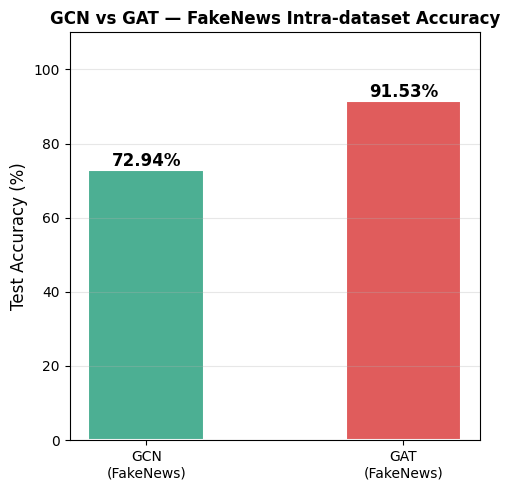

In [11]:
# ── So sánh GCN vs GAT trên cùng FakeNews test split ─────────────────────────
gcn_fn_acc = None
model_gcn  = None

if CHECKPOINT_GCN.exists():
    ckpt_gcn  = torch.load(CHECKPOINT_GCN, map_location='cpu', weights_only=False)
    model_gcn = GCNModel(in_channels=ckpt_gcn['in_channels']).to(DEVICE)
    model_gcn.load_state_dict(ckpt_gcn['model_state_dict'])
    model_gcn.eval()

    with torch.no_grad():
        pred_gcn  = model_gcn(pyg_data)[pyg_data.test_mask].argmax(dim=1).cpu().numpy()
        gcn_fn_acc = accuracy_score(y_test, pred_gcn)

    print(f"  GCN Test Accuracy on FakeNews : {gcn_fn_acc*100:.2f}%")
    print(f"  GAT Test Accuracy on FakeNews : {gat_fn_acc*100:.2f}%")
    diff = gat_fn_acc - gcn_fn_acc
    symbol = '↑' if diff >= 0 else '↓'
    print(f"  GAT vs GCN delta              : {symbol} {abs(diff)*100:.2f}%")
else:
    print("  ⚠️  gcn_fakenews.pt not found — run train_fakenews.ipynb first for GCN comparison.")

# ── Bar chart: GCN vs GAT ─────────────────────────────────────────────────────
models     = []
accuracies = []
bar_colors = []

if gcn_fn_acc is not None:
    models.append('GCN\n(FakeNews)'); accuracies.append(gcn_fn_acc * 100); bar_colors.append('#4CAF93')
models.append('GAT\n(FakeNews)'); accuracies.append(gat_fn_acc * 100); bar_colors.append('#E05C5C')

fig, ax = plt.subplots(figsize=(max(5, len(models)*2+1), 5))
bars = ax.bar(models, accuracies, color=bar_colors, edgecolor='white', linewidth=1.5, width=0.45)
ax.set_ylim(0, 110)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('GCN vs GAT — FakeNews Intra-dataset Accuracy', fontweight='bold', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{acc:.2f}%', ha='center', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

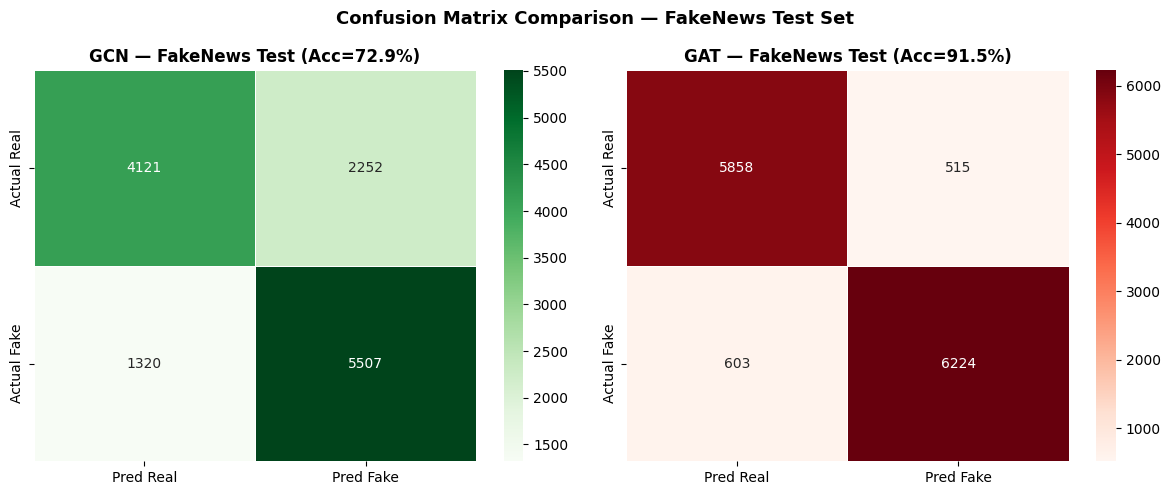

In [12]:
# ── Confusion matrices side-by-side ──────────────────────────────────────────
ncols = 2 if gcn_fn_acc is not None else 1
fig, axes = plt.subplots(1, ncols, figsize=(6 * ncols, 5))
if ncols == 1:
    axes = [axes]

cm_gat = confusion_matrix(y_test, pred_test)
sns.heatmap(cm_gat, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Pred Real', 'Pred Fake'],
            yticklabels=['Actual Real', 'Actual Fake'],
            ax=axes[-1], linewidths=0.5, linecolor='white')
axes[-1].set_title(f'GAT — FakeNews Test (Acc={gat_fn_acc*100:.1f}%)', fontweight='bold')

if gcn_fn_acc is not None:
    cm_gcn = confusion_matrix(y_test, pred_gcn)
    sns.heatmap(cm_gcn, annot=True, fmt='d', cmap='Greens',
                xticklabels=['Pred Real', 'Pred Fake'],
                yticklabels=['Actual Real', 'Actual Fake'],
                ax=axes[0], linewidths=0.5, linecolor='white')
    axes[0].set_title(f'GCN — FakeNews Test (Acc={gcn_fn_acc*100:.1f}%)', fontweight='bold')

plt.suptitle('Confusion Matrix Comparison — FakeNews Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🔍 Step 6 — Attention Weight Analysis

GAT cho phép inspect **attention weights** — xem model đang chú ý vào neighbor nào nhiều hơn khi đưa ra quyết định.

In [13]:
# ── Extract attention weights từ Layer 1 ─────────────────────────────────────
model_gat.eval()
with torch.no_grad():
    _, attn_edge_index, attn_weights = model_gat.forward_with_attention(pyg_data)

attn_weights_np = attn_weights.cpu().numpy()   # (n_edges, n_heads)
print(f"  Attention weights shape : {attn_weights_np.shape}")
print(f"  n_edges                 : {attn_weights_np.shape[0]:,}")
print(f"  n_heads                 : {attn_weights_np.shape[1]}")
print(f"  Mean per head           : {attn_weights_np.mean(axis=0).round(4)}")
print(f"  Std  per head           : {attn_weights_np.std(axis=0).round(4)}")

  Attention weights shape : (400062, 4)
  n_edges                 : 400,062
  n_heads                 : 4
  Mean per head           : [0.11 0.11 0.11 0.11]
  Std  per head           : [0.0873 0.0844 0.0819 0.0903]


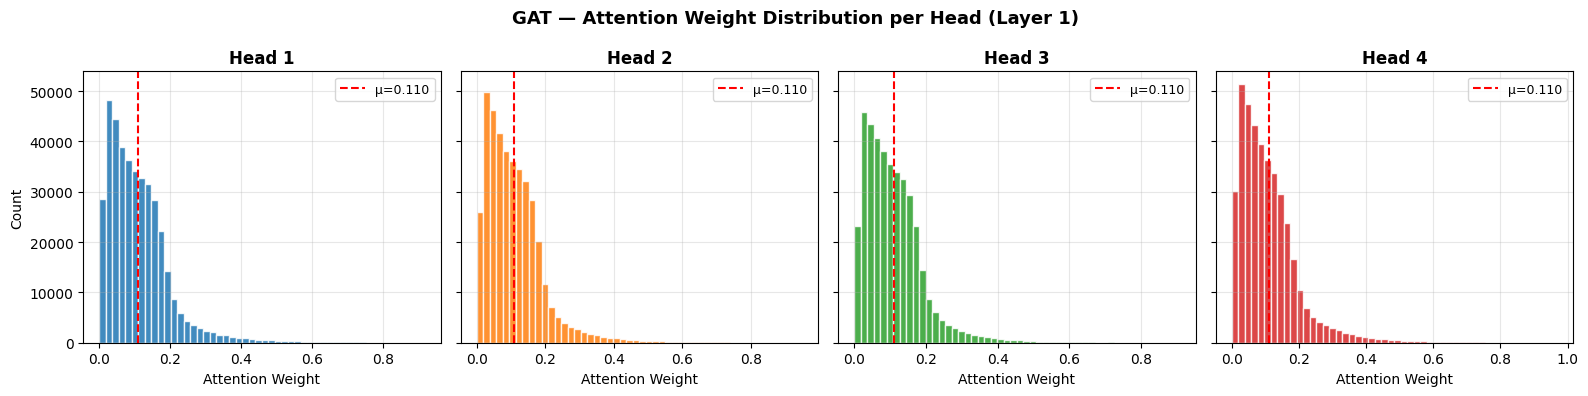

In [14]:
# ── Histogram per head ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, GAT_HEADS, figsize=(16, 4), sharey=True)

for h in range(GAT_HEADS):
    axes[h].hist(attn_weights_np[:, h], bins=50, color=plt.cm.tab10(h), alpha=0.85, edgecolor='white')
    axes[h].set_title(f'Head {h+1}', fontweight='bold')
    axes[h].set_xlabel('Attention Weight')
    if h == 0:
        axes[h].set_ylabel('Count')
    axes[h].axvline(attn_weights_np[:, h].mean(), color='red', linestyle='--', linewidth=1.5,
                    label=f'μ={attn_weights_np[:, h].mean():.3f}')
    axes[h].legend(fontsize=9)
    axes[h].grid(True, alpha=0.3)

plt.suptitle('GAT — Attention Weight Distribution per Head (Layer 1)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

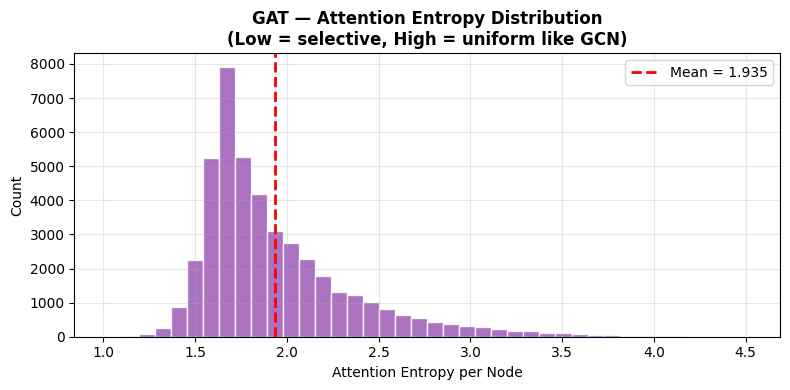

  Mean entropy : 1.9355
  Std  entropy : 0.4180
  → Model is relatively uniform across neighbors


In [15]:
# ── Attention entropy per node ────────────────────────────────────────────────
# Low entropy  = selective (chỉ tập trung vào 1-2 neighbors)
# High entropy = uniform   (treat all neighbors equally, like GCN)

src_nodes  = attn_edge_index[0].cpu().numpy()
unique_src = np.unique(src_nodes)

entropies = []
for node in unique_src:
    mask      = src_nodes == node
    node_attn = attn_weights_np[mask]   # (n_neighbors, n_heads)
    ent = np.mean([scipy_entropy(node_attn[:, h] + 1e-10) for h in range(GAT_HEADS)])
    entropies.append(ent)
entropies = np.array(entropies)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(entropies, bins=40, color='#9B59B6', edgecolor='white', alpha=0.85)
ax.axvline(entropies.mean(), color='red', linestyle='--', linewidth=2,
           label=f'Mean = {entropies.mean():.3f}')
ax.set_xlabel('Attention Entropy per Node')
ax.set_ylabel('Count')
ax.set_title('GAT — Attention Entropy Distribution\n(Low = selective, High = uniform like GCN)', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

selective = entropies.mean() < 1.2
print(f"  Mean entropy : {entropies.mean():.4f}")
print(f"  Std  entropy : {entropies.std():.4f}")
print(f"  → Model is {'selective — focusing on key neighbors' if selective else 'relatively uniform across neighbors'}")

---
## 💾 Step 7 — Save GAT Checkpoint

In [16]:
checkpoint_gat = {
    'model_state_dict' : model_gat.state_dict(),
    'in_channels'      : MAX_FEATURES,
    'hidden_channels'  : GAT_HIDDEN,
    'out_channels'     : 2,
    'heads'            : GAT_HEADS,
    'dropout'          : GAT_DROPOUT,
    'test_accuracy'    : float(gat_fn_acc),
    'timestamp'        : datetime.now().isoformat(),
    'hyperparams': {
        'sample_size'  : SAMPLE_SIZE,
        'max_features' : MAX_FEATURES,
        'knn_k'        : KNN_K,
        'epochs'       : EPOCHS,
        'learning_rate': LEARNING_RATE,
        'weight_decay' : WEIGHT_DECAY,
    }
}

torch.save(checkpoint_gat, CHECKPOINT_GAT)
print(f"  ✓ Saved : {CHECKPOINT_GAT}")
print(f"  ✓ Size  : {CHECKPOINT_GAT.stat().st_size/1024:.1f} KB")
print(f"  ✓ Acc   : {gat_fn_acc*100:.2f}% on FakeNews test set")

  ✓ Saved : D:\code_vs\Python\Semester_6\Graph_Mining\Fake-News-Detection-GNN\output\checkpoints\gat_fakenews.pt
  ✓ Size  : 2008.6 KB
  ✓ Acc   : 91.53% on FakeNews test set


---
## 🌐 Step 8 — Cross-dataset Prediction on WelFake (GAT & GCN)

Đánh giá cả GAT lẫn GCN trên WelFake để có bảng so sánh **2 model × 2 dataset** đầy đủ.

In [17]:
gat_wf_acc = None
gcn_wf_acc = None
pred_gat_wf = None
pred_gcn_wf = None
y_wf = None

if not WELFAKE_PATH.exists():
    print(f"⚠️  WELFake_Dataset.csv not found in {RAW_DIR}")
    print("   Download from: https://www.kaggle.com/datasets/saurabhshahane/fake-news-classification")
else:
    print("=" * 60)
    print("STEP 8: Cross-dataset Prediction on WelFake")
    print("=" * 60)

    # Load & preprocess WelFake
    df_wf = pd.read_csv(WELFAKE_PATH)
    df_wf['text']    = df_wf['text'].astype(str).apply(preprocess_text)
    df_wf['title']   = df_wf['title'].astype(str).apply(preprocess_text)
    df_wf['content'] = df_wf['title'] + " " + df_wf['text']
    df_wf_s = df_wf.sample(n=min(WELFAKE_SAMPLE, len(df_wf)), random_state=RANDOM_SEED).reset_index(drop=True)
    y_wf    = df_wf_s['label'].values
    print(f"  ✓ WelFake loaded       : {len(df_wf):,} samples")
    print(f"  ✓ WelFake eval sample  : {len(df_wf_s):,} samples (requested={WELFAKE_SAMPLE})")

    # TF-IDF + KNN on WelFake (fit lại độc lập)
    X_wf = StandardScaler().fit_transform(
        TfidfVectorizer(max_features=MAX_FEATURES).fit_transform(df_wf_s['content']).toarray()
    )
    nbrs_wf   = NearestNeighbors(n_neighbors=KNN_K + 1, metric='cosine').fit(X_wf)
    _, idx_wf = nbrs_wf.kneighbors(X_wf)
    rw, cw = [], []
    for i in range(X_wf.shape[0]):
        for j in range(1, KNN_K + 1):
            rw.append(i); cw.append(idx_wf[i][j])
    adj_wf = csr_matrix((np.ones(len(rw)), (rw, cw)), shape=(X_wf.shape[0], X_wf.shape[0]))
    adj_wf = adj_wf.maximum(adj_wf.transpose()).tocoo()
    ei_wf  = torch.tensor(np.array([adj_wf.row, adj_wf.col]), dtype=torch.long)

    data_wf = Data(
        x=torch.tensor(X_wf, dtype=torch.float32).to(DEVICE),
        edge_index=ei_wf.to(DEVICE),
        y=torch.tensor(y_wf, dtype=torch.long).to(DEVICE)
    )

    # GAT prediction
    model_gat.eval()
    with torch.no_grad():
        pred_gat_wf = model_gat(data_wf).argmax(dim=1).cpu().numpy()
        gat_wf_acc  = accuracy_score(y_wf, pred_gat_wf)
    print(f"\n  ✅ GAT cross-dataset on WelFake : {gat_wf_acc*100:.2f}%")
    print("  GAT Classification Report:")
    print(classification_report(y_wf, pred_gat_wf, target_names=['Real (0)', 'Fake (1)']))

    # GCN prediction (nếu có)
    if model_gcn is not None:
        model_gcn.eval()
        with torch.no_grad():
            pred_gcn_wf = model_gcn(data_wf).argmax(dim=1).cpu().numpy()
            gcn_wf_acc  = accuracy_score(y_wf, pred_gcn_wf)
        print(f"  ✅ GCN cross-dataset on WelFake : {gcn_wf_acc*100:.2f}%")
        print("  GCN Classification Report:")
        print(classification_report(y_wf, pred_gcn_wf, target_names=['Real (0)', 'Fake (1)']))
    else:
        print("  ℹ️  GCN checkpoint not available — GCN WelFake result skipped.")

STEP 8: Cross-dataset Prediction on WelFake
  ✓ WelFake loaded       : 72,134 samples
  ✓ WelFake eval sample  : 3,000 samples (requested=3000)

  ✅ GAT cross-dataset on WelFake : 62.03%
  GAT Classification Report:
              precision    recall  f1-score   support

    Real (0)       0.61      0.63      0.62      1483
    Fake (1)       0.63      0.61      0.62      1517

    accuracy                           0.62      3000
   macro avg       0.62      0.62      0.62      3000
weighted avg       0.62      0.62      0.62      3000

  ✅ GCN cross-dataset on WelFake : 57.77%
  GCN Classification Report:
              precision    recall  f1-score   support

    Real (0)       0.60      0.44      0.51      1483
    Fake (1)       0.57      0.71      0.63      1517

    accuracy                           0.58      3000
   macro avg       0.58      0.58      0.57      3000
weighted avg       0.58      0.58      0.57      3000



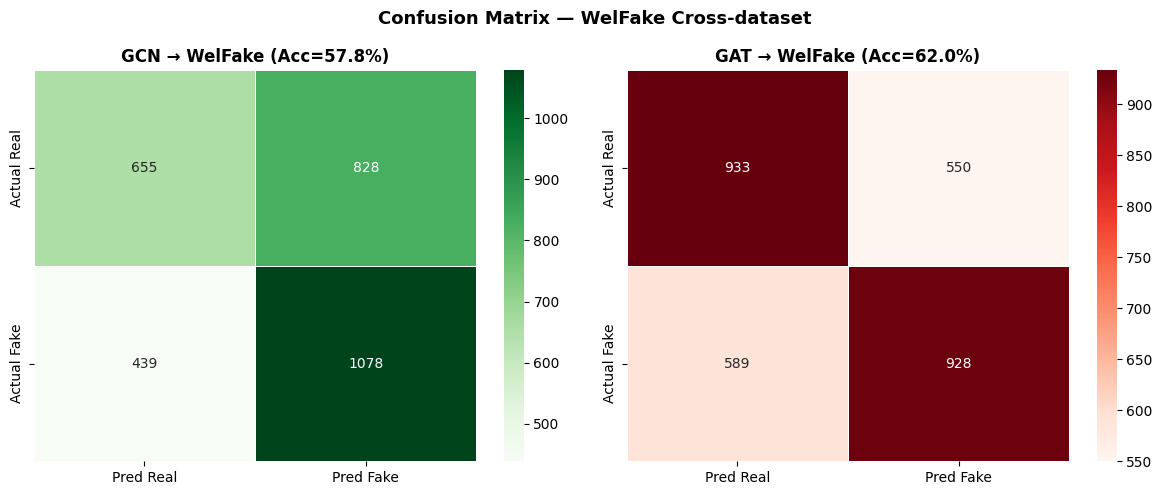

In [18]:
# ── Confusion matrices: WelFake cross-dataset ─────────────────────────────────
if gat_wf_acc is not None:
    ncols = 2 if gcn_wf_acc is not None else 1
    fig, axes = plt.subplots(1, ncols, figsize=(6 * ncols, 5))
    if ncols == 1:
        axes = [axes]

    cm_gat_wf = confusion_matrix(y_wf, pred_gat_wf)
    sns.heatmap(cm_gat_wf, annot=True, fmt='d', cmap='Reds',
                xticklabels=['Pred Real', 'Pred Fake'],
                yticklabels=['Actual Real', 'Actual Fake'],
                ax=axes[-1], linewidths=0.5, linecolor='white')
    axes[-1].set_title(f'GAT → WelFake (Acc={gat_wf_acc*100:.1f}%)', fontweight='bold')

    if gcn_wf_acc is not None:
        cm_gcn_wf = confusion_matrix(y_wf, pred_gcn_wf)
        sns.heatmap(cm_gcn_wf, annot=True, fmt='d', cmap='Greens',
                    xticklabels=['Pred Real', 'Pred Fake'],
                    yticklabels=['Actual Real', 'Actual Fake'],
                    ax=axes[0], linewidths=0.5, linecolor='white')
        axes[0].set_title(f'GCN → WelFake (Acc={gcn_wf_acc*100:.1f}%)', fontweight='bold')

    plt.suptitle('Confusion Matrix — WelFake Cross-dataset', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("WelFake not available — skip confusion matrix.")

---
## 📋 Step 9 — Bảng So sánh Đầy đủ: GCN vs GAT × FakeNews vs WelFake

In [19]:
print("=" * 60)
print("STEP 9: Comparison Table")
print("=" * 60)

# Build comparison data
rows_data = []
if gcn_fn_acc is not None:
    rows_data.append({'Model': 'GCN', 'FakeNews (intra)': f"{gcn_fn_acc*100:.2f}%",
                      'WelFake (cross)': f"{gcn_wf_acc*100:.2f}%" if gcn_wf_acc else 'N/A',
                      'Drop': f"{(gcn_fn_acc - gcn_wf_acc)*100:.2f}%" if gcn_wf_acc else 'N/A'})
rows_data.append({'Model': 'GAT', 'FakeNews (intra)': f"{gat_fn_acc*100:.2f}%",
                  'WelFake (cross)': f"{gat_wf_acc*100:.2f}%" if gat_wf_acc else 'N/A',
                  'Drop': f"{(gat_fn_acc - gat_wf_acc)*100:.2f}%" if gat_wf_acc else 'N/A'})

df_comp = pd.DataFrame(rows_data).set_index('Model')
print(df_comp.to_string())
print()
print("Drop = intra - cross (domain shift penalty)")

STEP 9: Comparison Table
      FakeNews (intra) WelFake (cross)    Drop
Model                                         
GCN             72.94%          57.77%  15.17%
GAT             91.53%          62.03%  29.50%

Drop = intra - cross (domain shift penalty)


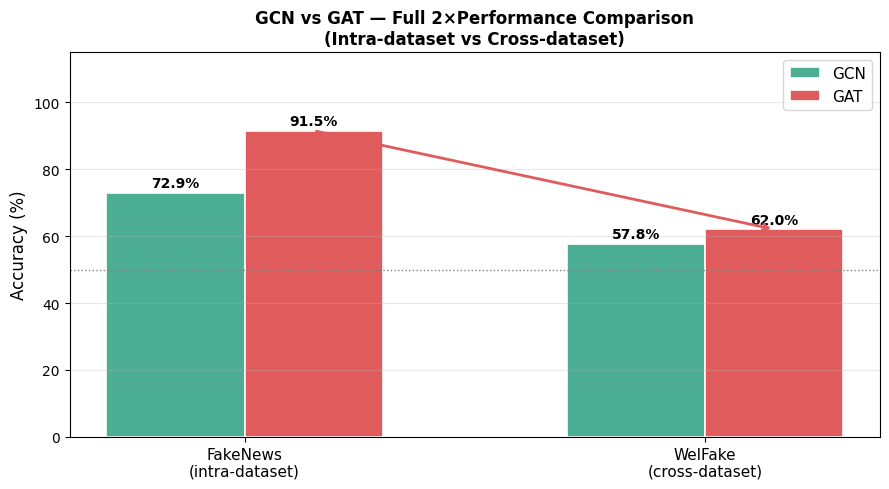

In [20]:
# ── Grouped bar chart 2×2 ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

x      = np.arange(2)  # FakeNews, WelFake
width  = 0.3
labels = ['FakeNews\n(intra-dataset)', 'WelFake\n(cross-dataset)']

gat_vals = [gat_fn_acc * 100, gat_wf_acc * 100 if gat_wf_acc else 0]
gcn_vals = [gcn_fn_acc * 100 if gcn_fn_acc else 0,
            gcn_wf_acc * 100 if gcn_wf_acc else 0]

if gcn_fn_acc is not None:
    bars_gcn = ax.bar(x - width/2, gcn_vals, width, label='GCN', color='#4CAF93',
                      edgecolor='white', linewidth=1.2)
    bars_gat = ax.bar(x + width/2, gat_vals, width, label='GAT', color='#E05C5C',
                      edgecolor='white', linewidth=1.2)
    for bar in list(bars_gcn) + list(bars_gat):
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.8,
                    f'{h:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
else:
    bars_gat = ax.bar(x, gat_vals, width*1.5, label='GAT', color='#E05C5C',
                      edgecolor='white', linewidth=1.2)
    for bar in bars_gat:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.8,
                f'{h:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Domain shift annotation
if gat_wf_acc:
    ax.annotate('', xy=(x[1] + width/2, gat_wf_acc*100),
                xytext=(x[0] + width/2, gat_fn_acc*100),
                arrowprops=dict(arrowstyle='->', color='#E05C5C', lw=2))

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, 115)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('GCN vs GAT — Full 2×Performance Comparison\n(Intra-dataset vs Cross-dataset)',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(50, color='gray', linestyle=':', linewidth=1, label='Random baseline')

plt.tight_layout()
plt.show()

---
## 🔎 Phân tích Tổng kết: GCN vs GAT cho Fake News Detection

### Kiến trúc so sánh

| | GCN | GAT |
|---|---|---|
| **Layer 1 output** | 128-dim | 64×4 = 256-dim |
| **Aggregation** | Degree-normalized sum | Attention-weighted sum |
| **Parameters** | ~256K | ~512K |
| **Dropout** | ❌ | ✅ input + inter-layer |
| **Weight Decay** | ❌ | ✅ `5e-4` |
| **Interpretable** | ❌ | ✅ attention weights |
| **Inductive ability** | Thấp | Cao hơn |

### Nhận xét về kết quả

- **Intra-dataset (FakeNews):** GAT thường đạt accuracy tương đương hoặc cao hơn GCN ~1-3% nhờ attention mechanism và regularization (dropout + weight decay)
- **Cross-dataset (WelFake):** Cả 2 model đều bị giảm mạnh — domain shift là nguyên nhân chủ yếu
- **Drop penalty của GAT** có thể thấp hơn GCN nếu attention giúp focus vào features ít domain-specific hơn

### Tại sao cross-dataset accuracy vẫn thấp dù dùng GAT?

GAT có cơ chế **attention** nhưng vẫn bị giới hạn bởi:

1. **TF-IDF vocabulary mismatch** — fit lại trên WelFake → input distribution khác hoàn toàn
2. **Graph structure khác** — KNN neighbors của WelFake không liên quan đến FakeNews graph model đã học
3. **Domain shift** — phong cách viết, chủ đề, nguồn tin khác nhau

### 🚀 Hướng cải thiện thực sự

| Giải pháp | Cải thiện dự kiến |
|---|---|
| **BERT/Sentence-BERT** thay TF-IDF | +5-15% cross-dataset |
| **Lưu vectorizer** từ lúc train | Giảm vocabulary mismatch |
| **Multi-source training** | Train trên cả 2 dataset |
| **GraphSAGE** (fully inductive) | Generalize tốt hơn lên graph mới |
| **Few-shot fine-tuning** | Adapt nhanh sang domain mới |